In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Load your CSV data
csv_file = 'results/all_pool=central.csv'  # replace with your file path
df = pd.read_csv(csv_file)
df = df.sort_values(by="d")


def plot(df, numfeatureslist, name):

    df = df[df.numfeatures.isin(numfeatureslist)]

    # Interpolators dictionary for each (policy, d) pair
    interpolators = {}

    # Create interpolators for each policy and each d
    for (policy, d), group in df.groupby(['policy', 'numfeatures']):
        group_sorted = group.sort_values(by='policy_cost')
        interpolators[(policy, d)] = interp1d(group_sorted['policy_cost'], group_sorted['post_transfer_poverty_rate'], 
                                            bounds_error=False)

    print(interpolators)

    # Define a specific policy_cost for plotting
    costs = [0.7, 0.8, 0.9, 1.0]  # replace with your chosen policy_cost

    # List unique values of d
    unique_ds = df['numfeatures'].unique()

    # Plot the results
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    for chosen_policy_cost in costs:
        # Calculate the ratio of post_transfer_poverty_rate between "conditional_optimized" and "optimized"
        ratios = []
        for d in unique_ds:
            if ('conditional_optimized', d) in interpolators and ('optimized', d) in interpolators:
                cond_opt_poverty_rate = interpolators[('conditional_optimized', d)](chosen_policy_cost)
                opt_poverty_rate = interpolators[('optimized', d)](chosen_policy_cost)
                ratio = cond_opt_poverty_rate / opt_poverty_rate
                ratios.append((d, ratio))
        print(ratios)

        
        # Convert ratios to a DataFrame for easier plotting
        ratios_df = pd.DataFrame(ratios, columns=['numfeatures', 'ratio'])
        ratios_df.to_csv("results/ratios_B={}.csv".format(chosen_policy_cost))
        plt.plot(ratios_df['numfeatures'], ratios_df['ratio'], marker='o', linestyle='-',  label='B={}'.format(chosen_policy_cost))

    ax.set_ylim(0.8, 1.15)
    ax.set_xlim(-0.25 + 0, 9 + 0.25)
    plt.axhline(y=1, color='black', linestyle='--', label='Ratio = 1')
    plt.xlabel('Number of Features', fontsize=15)
    plt.ylabel('Post-Transfer Poverty Rate Ratio', fontsize=15)
    plt.title(f'Post-Transfer Poverty Rate Ratio vs. Number of Features', fontsize=20)
    plt.legend(fontsize=15,loc="lower left")
    plt.grid(True)
    plt.savefig("figs/{}_features.pdf".format(name))
    plt.show()

{('conditional_optimized', 1): <scipy.interpolate._interpolate.interp1d object at 0x76ae0d524950>, ('conditional_optimized', 2): <scipy.interpolate._interpolate.interp1d object at 0x76ae0d5245e0>, ('optimized', 1): <scipy.interpolate._interpolate.interp1d object at 0x76ae24fb2bb0>, ('optimized', 2): <scipy.interpolate._interpolate.interp1d object at 0x76ae129d79c0>}
[(1, 1.1084760666397049), (2, 1.0484632625216468)]
[(1, 1.0950961535835162), (2, 1.0605665067356802)]
[(1, 1.0648395014607521), (2, 1.050933457572619)]
[(1, 1.0708762438740551), (2, 1.0375531447499498)]


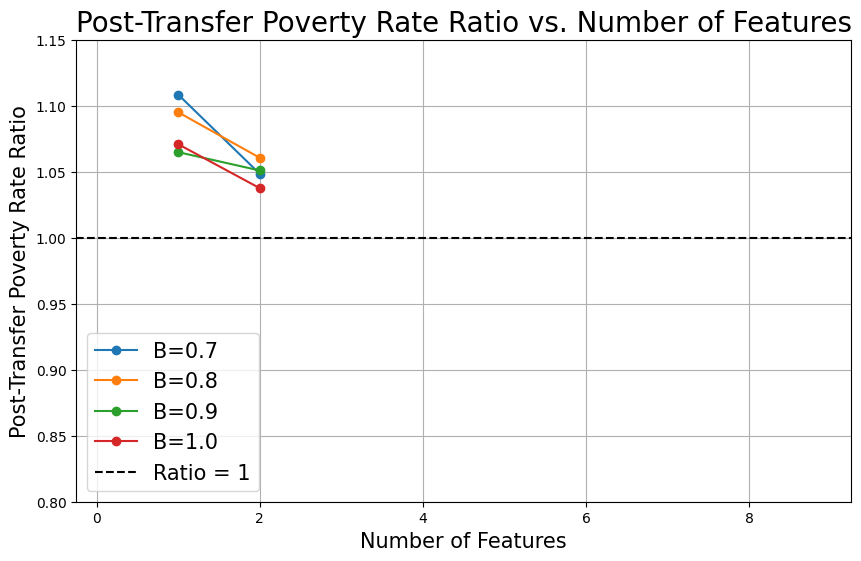

In [5]:
plot(df, [1, 2], "lowdim")

{('conditional_optimized', 1): <scipy.interpolate._interpolate.interp1d object at 0x76ae0d59acf0>, ('conditional_optimized', 2): <scipy.interpolate._interpolate.interp1d object at 0x76ae0d5500e0>, ('conditional_optimized', 3): <scipy.interpolate._interpolate.interp1d object at 0x76ae0d553c90>, ('conditional_optimized', 4): <scipy.interpolate._interpolate.interp1d object at 0x76ae1290eca0>, ('conditional_optimized', 5): <scipy.interpolate._interpolate.interp1d object at 0x76ae0d552bb0>, ('conditional_optimized', 6): <scipy.interpolate._interpolate.interp1d object at 0x76ae2cdd2e30>, ('conditional_optimized', 7): <scipy.interpolate._interpolate.interp1d object at 0x76ae129439c0>, ('conditional_optimized', 8): <scipy.interpolate._interpolate.interp1d object at 0x76ae0d598d60>, ('conditional_optimized', 9): <scipy.interpolate._interpolate.interp1d object at 0x76ae0d553510>, ('optimized', 1): <scipy.interpolate._interpolate.interp1d object at 0x76ae12943600>, ('optimized', 2): <scipy.interp

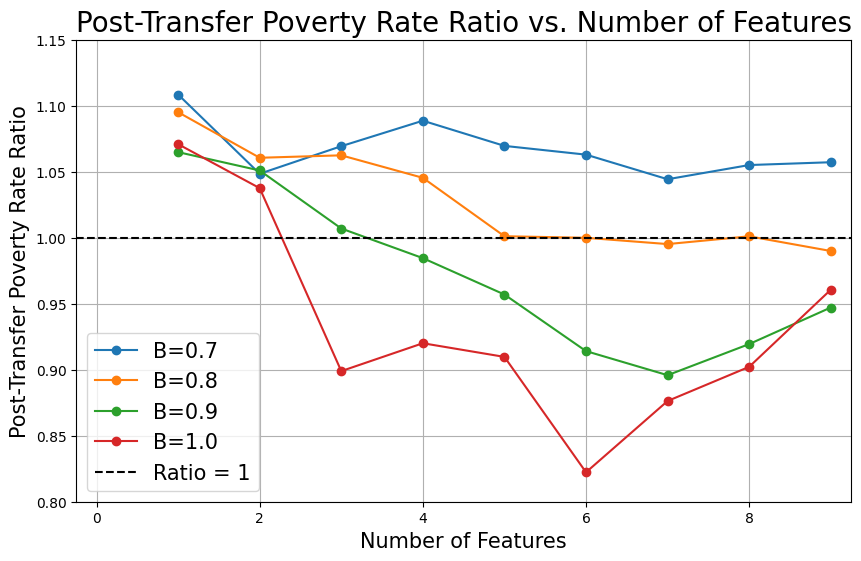

In [6]:
plot(df, [1, 2, 3, 4, 5, 6, 7, 8, 9], "highdim")